In [93]:
from sklearn.preprocessing import scale
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [94]:
kmeans = KMeans(n_clusters=3,
                init='k-means++',
                max_iter=300,
                random_state=42)

kmeans.fit(df)
print(kmeans.labels_)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 0 0 0 2 0 0 0 0
 0 0 2 2 0 0 0 0 2 0 2 0 2 0 0 2 2 0 0 0 0 0 2 0 0 0 0 2 0 0 0 2 0 0 0 2 0
 0 2]


In [95]:
df['target'] = iris.target
df['cluster'] = kmeans.labels_
res = df.groupby(['target', 'cluster'])['sepal length (cm)'].count()
print(res)

target  cluster
0       1          50
1       0           3
        2          47
2       0          36
        2          14
Name: sepal length (cm), dtype: int64


In [96]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
df_pca = pca.fit_transform(iris.data)

df['pca_1'] = df_pca[:,0]
df['pca_2'] = df_pca[:,1]
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,cluster,pca_1,pca_2
0,5.1,3.5,1.4,0.2,0,1,-2.684126,0.319397
1,4.9,3.0,1.4,0.2,0,1,-2.714142,-0.177001
2,4.7,3.2,1.3,0.2,0,1,-2.888991,-0.144949
3,4.6,3.1,1.5,0.2,0,1,-2.745343,-0.318299
4,5.0,3.6,1.4,0.2,0,1,-2.728717,0.326755


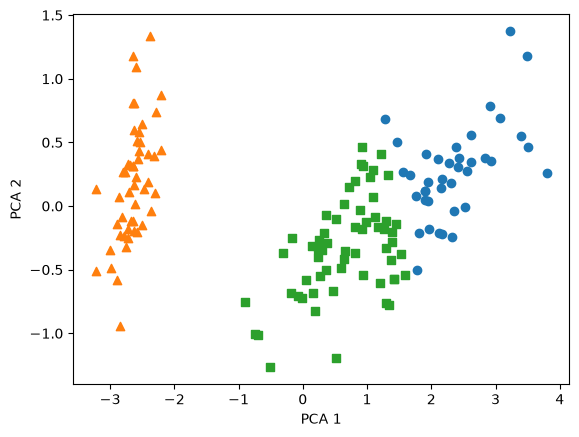

In [97]:
marker0 = df[df['cluster'] == 0].index
marker1 = df[df['cluster'] == 1].index
marker2 = df[df['cluster'] == 2].index

plt.scatter(x=df.loc[marker0, 'pca_1'],
            y=df.loc[marker0, 'pca_2'],
            marker='o')
plt.scatter(x=df.loc[marker1, 'pca_1'],
            y=df.loc[marker1, 'pca_2'],
            marker='^')
plt.scatter(x=df.loc[marker2, 'pca_1'],
            y=df.loc[marker2, 'pca_2'],
            marker='s')

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

In [98]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=200,
                  n_features=2,
                  centers=3,
                  cluster_std=1.5,
                  random_state=42)

print(X.shape, y.shape)

(200, 2) (200,)


In [99]:
unique, counts = np.unique(y, return_counts=True)
print(unique, counts)

[0 1 2] [67 67 66]


In [100]:
import pandas as pd

df_cls = pd.DataFrame(data=X, columns=['ftr1', 'ftr2'])
df_cls['target'] = y
df_cls.head()

,ftr1,ftr2,target
0,7.438541,2.683919,1
1,-6.438815,10.247140,0
2,-6.897997,-8.225991,2
3,-9.051754,-8.991305,2
4,-7.763674,-5.605706,2


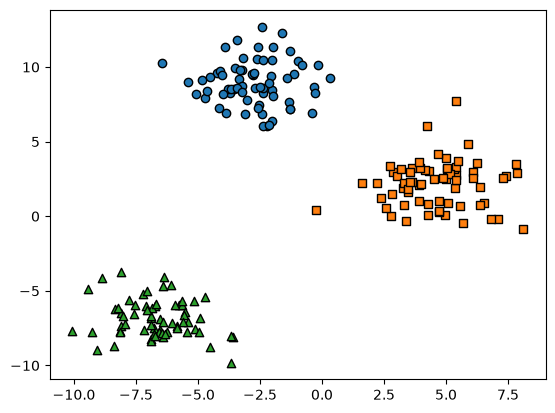

In [101]:
target_list = np.unique(y)

markers = ['o', 's', '^', 'P', 'D', 'H', 'x']

for target in target_list:
    target_cluster = df_cls[df_cls['target'] == target]
    plt.scatter(x=target_cluster['ftr1'],
                y=target_cluster['ftr2'],
                edgecolor='k',
                marker=markers[target])

plt.show()

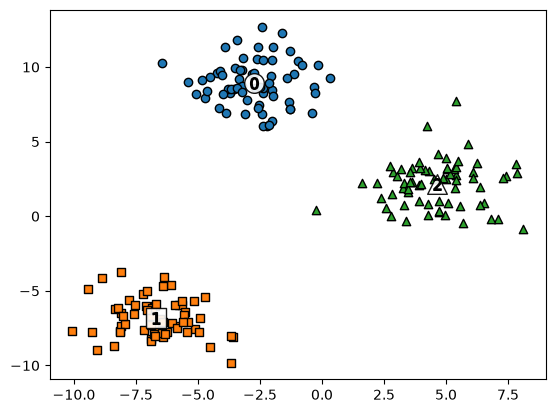

In [102]:
kmeans = KMeans(n_clusters=3,
                init='k-means++',
                max_iter=200,
                random_state=42)

cluster_labels = kmeans.fit_predict(X)
df_cls['kmeans_label'] = cluster_labels

centers = kmeans.cluster_centers_
unique_labels = np.unique(cluster_labels)

markers = ['o', 's', '^', 'P', 'D', 'H', 'x']

for label in unique_labels:
    label_cluster = df_cls[df_cls['kmeans_label'] == label]
    center = centers[label]
    plt.scatter(x=label_cluster['ftr1'],
                y=label_cluster['ftr2'],
                edgecolor='k',
                marker=markers[label])
    
    plt.scatter(x=center[0],
                y=center[1],
                s=200,
                color='white',
                alpha=0.9,
                edgecolor='k',
                marker=markers[label])
    
    plt.scatter(x=center[0],
                y=center[1],
                s=70,
                color='k',
                edgecolor='k',
                marker='$%d$' % label)

plt.show()

In [103]:
print(df_cls.groupby('target')['kmeans_label'].value_counts())

target  kmeans_label
0       0               67
1       2               67
2       1               66
Name: count, dtype: int64


In [106]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.cluster import MeanShift

X, y = make_blobs(n_samples=200,
                  n_features=2,
                  centers=3,
                  cluster_std=0.7,
                  random_state=42)

meanshift = MeanShift(bandwidth=1.5)
cluster_labels = meanshift.fit_predict(X)
print(np.unique(cluster_labels))

[0 1 2]


In [107]:
meanshift = MeanShift(bandwidth=1.0)
cluster_labels = meanshift.fit_predict(X)
print(np.unique(cluster_labels))

[0 1 2 3 4]


In [112]:
from sklearn.cluster import estimate_bandwidth

bandwidth = estimate_bandwidth(X)
print(round(bandwidth, 3))

1.877


In [114]:
df = pd.DataFrame(data=X,
                  columns=['ftr1', 'ftr2'])
df['target'] = y

best_bandwidth = estimate_bandwidth(X)

meanshift = MeanShift(bandwidth = best_bandwidth)
cluster_labels = meanshift.fit_predict(X)
print(np.unique(cluster_labels))

[0 1 2]


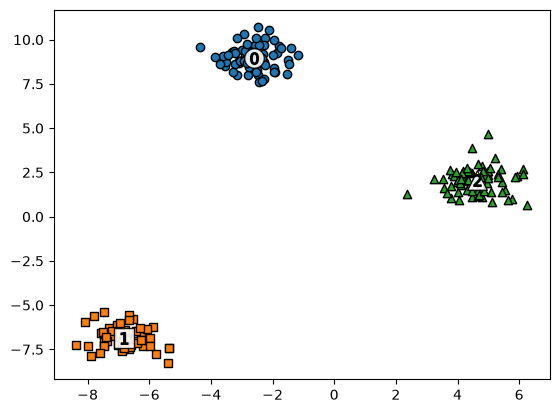

In [116]:
import matplotlib.pyplot as plt

df['meanshift_label'] = cluster_labels
centers = meanshift.cluster_centers_
unique_labels = np.unique(cluster_labels)

markers = ['o', 's', '^', 'P', 'D', 'H', 'x']

for label in unique_labels:
    label_cluster = df[df['meanshift_label'] == label]
    center = centers[label]

    plt.scatter(x=label_cluster['ftr1'],
                y=label_cluster['ftr2'],
                edgecolor='k',
                marker=markers[label])
    
    plt.scatter(x=center[0],
                y=center[1],
                s=200,
                color='white',
                alpha=0.9,
                edgecolor='k',
                marker=markers[label])
    
    plt.scatter(x=center[0],
                y=center[1],
                s=70,
                color='k',
                edgecolor='k',
                marker='$%d$' % label)

plt.show()

In [117]:
print(df.groupby('target')['meanshift_label'].value_counts())

target  meanshift_label
0       0                  67
1       2                  67
2       1                  66
Name: count, dtype: int64
